# 線性回歸濃縮草案

這一份把舊的測驗實驗 10（單變量）和 11（多變量）收成一本。`01` 到 `11` 沒有改。

你是連鎖餐廳的執行長，要決定哪些城市值得開新店。第一部只用城市人口預測每月獲利。第二部再加上當地收入，並看特徵尺度不同時梯度下降會怎樣。

程式已經寫好，用來讓你看懂模型在做什麼。請 agent 改的格子，標題會寫「實驗」。下面這種格子只有你能寫，agent 不要填、不要改寫：

### 你的觀察


## 給 agent

- 可以改標題含「實驗」的程式格，也可以依學生當下的問題加新的程式格。
- 不要改標題是「你的觀察」的格子，也不要替學生寫結論。
- 不要把 `compute_cost`、`compute_gradient` 重寫成另一套作業，除非學生明確說要改哪一行來做實驗。
- 學生若只說「幫我做完」，先問他現在想驗證什麼，再改程式。


## 第一部：只用人口預測獲利

品牌已經在一些城市有店，手上有各城市人口，以及該店每月獲利（負值是虧損）。人口的單位是萬人，獲利的單位是萬美元。第一筆人口約 `4.62`，也就是約 46,200 人；獲利約 `2.82`，也就是每月約 28,200 美元。

先跑下一格，看資料長什麼樣子。


筆數 m = 97
人口前 5 筆（萬人） [4.6189 4.6254 4.7058 4.7289 4.747 ]
獲利前 5 筆（萬美元） [ 2.8203  0.6921 -1.3984  1.3949  2.384 ]


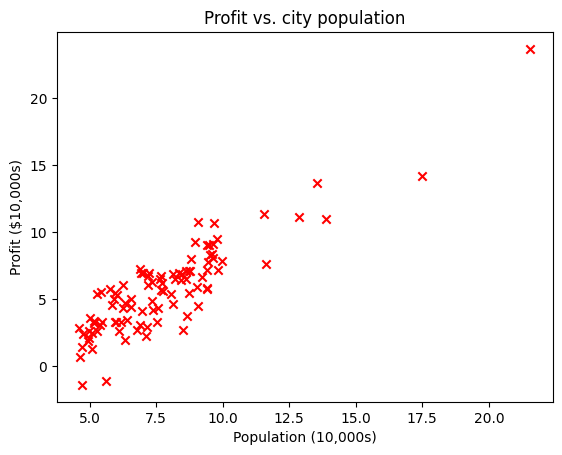

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def find_data_dir() -> Path:
    notebook_name = "線性回歸_濃縮草案.ipynb"
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        for folder in (root, root / "線性回歸", root / "linear-regression"):
            data_file = folder / "data" / "ex1data1.txt"
            if (folder / notebook_name).is_file() and data_file.is_file():
                return data_file.parent
    raise FileNotFoundError("找不到和這本 notebook 放在一起的 data/ex1data1.txt。")

DATA_DIR = find_data_dir()
rows = np.loadtxt(DATA_DIR / "ex1data1.txt", delimiter=",")
x_train = rows[:, 0]
y_train = rows[:, 1]
print("筆數 m =", len(x_train))
print("人口前 5 筆（萬人）", x_train[:5])
print("獲利前 5 筆（萬美元）", y_train[:5])

plt.scatter(x_train, y_train, marker="x", c="r")
plt.title("Profit vs. city population")
plt.xlabel("Population (10,000s)")
plt.ylabel("Profit ($10,000s)")
plt.show()


### 你的觀察

看完散點再寫。agent 不要填。

人口變多時，獲利看起來怎麼走？有沒有哪幾點明顯離群？


## 模型是一條線

單變量時，預測寫成

$$\hat{y} = wx + b$$

`w` 是斜率，人口每多一萬人，獲利預測要加多少。`b` 是人口為 0 時的基準，這份資料裡沒有這種城市，它只是把線搬上搬下。

下一格畫三條線，`b` 先固定為 0。這是實驗格，可以請 agent 改 `w` 再跑一次。


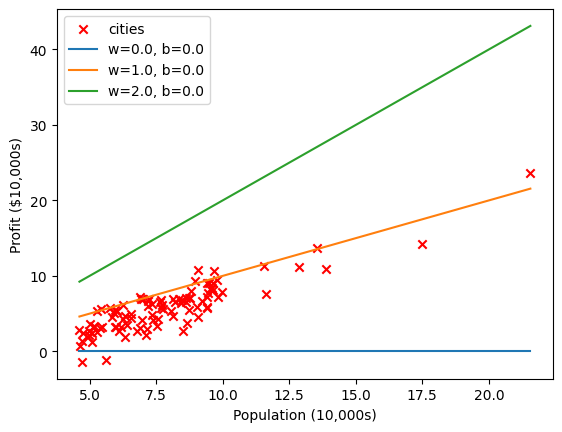

In [3]:
# 實驗：改 ws，看線怎麼斜
ws = [0.0, 1.0, 2.0]
b_fixed = 0.0
x_line = np.linspace(x_train.min(), x_train.max(), 50)

plt.scatter(x_train, y_train, marker="x", c="r", label="cities")
for w in ws:
    plt.plot(x_line, w * x_line + b_fixed, label=f"w={w}, b={b_fixed}")
plt.xlabel("Population (10,000s)")
plt.ylabel("Profit ($10,000s)")
plt.legend()
plt.show()


## Cost：這組 w、b 錯多少

每一個城市都有誤差：預測減掉實際獲利。Cost 是全部城市的平方誤差，再平均，前面乘 `1/(2m)`。平方讓正的誤差和負的誤差不會互相抵消。`1/2` 是為了後面微分時比較乾淨，不改變「哪一組 w、b 比較好」。

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (wx^{(i)} + b - y^{(i)})^2$$

函式先給你看，不必重寫。


In [4]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    total = 0.0
    for i in range(m):
        prediction = w * x[i] + b
        total += (prediction - y[i]) ** 2
    return total / (2 * m)

print(f"w=2, b=1 的 Cost = {compute_cost(x_train, y_train, 2, 1):.3f}")
print("舊測驗這組參數的參考值是 62.639")


w=2, b=1 的 Cost = 62.639
舊測驗這組參數的參考值是 62.639


In [5]:
# 實驗：拿掉平方會怎樣。三個點，誤差是 +1、0、-1。
x_tiny = np.array([1.0, 2.0, 3.0])
y_tiny = np.array([1.0, 2.0, 3.0])
w_try, b_try = 0.0, 2.0
errors = w_try * x_tiny + b_try - y_tiny
print("誤差", errors)
print("直接相加", errors.sum())
print("平方後相加", np.square(errors).sum())


誤差 [ 1.  0. -1.]
直接相加 0.0
平方後相加 2.0


### 你的觀察

agent 不要填。

誤差直接相加變成 0，平方之後不是。若 Cost 用相加而不平方，模型會以為自己沒有錯嗎？


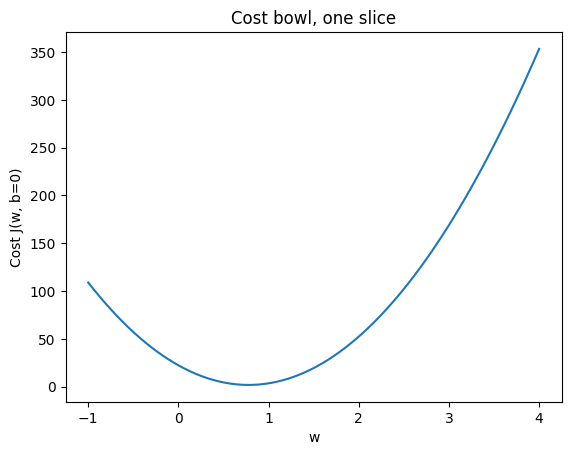

In [6]:
# w 從 -1 掃到 4，b 固定為 0。Cost 對 w 是一條開口向上的曲線。
w_grid = np.linspace(-1, 4, 80)
costs = [compute_cost(x_train, y_train, w, 0.0) for w in w_grid]
plt.plot(w_grid, costs)
plt.xlabel("w")
plt.ylabel("Cost J(w, b=0)")
plt.title("Cost bowl, one slice")
plt.show()


## 梯度下降：沿著碗往下走

訓練不是把公式解完，是重複做同一件事：看現在的 `w`、`b` 往哪邊改，Cost 會下降，就往那邊走一小步。步長是學習率 `alpha`。

單變量的梯度是：

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum (\hat{y}^{(i)} - y^{(i)})$$

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum (\hat{y}^{(i)} - y^{(i)}) x^{(i)}$$

下面的梯度與迴圈沿用測驗 10，數字對得上舊的參考值。這一節不是叫你重寫函式。


w=0, b=0 的梯度 -52.7552513627835 -5.755578350515463
舊測驗參考值約 -52.755 與 -5.756
Iteration    0: Cost     3.78
Iteration  150: Cost     1.63
Iteration  300: Cost     1.52
Iteration  450: Cost     1.45
Iteration  600: Cost     1.39
Iteration  750: Cost     1.35
Iteration  900: Cost     1.32
Iteration 1050: Cost     1.29
Iteration 1200: Cost     1.28
Iteration 1350: Cost     1.26
學到的 w, b = 1.0598399738618864 -2.443276684796425
舊測驗參考值約 w=1.060, b=-2.443


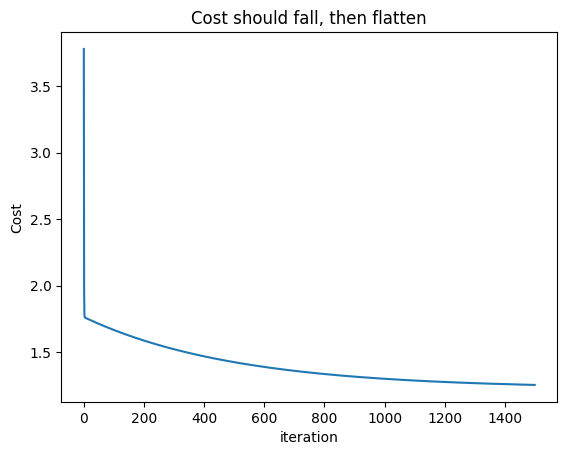

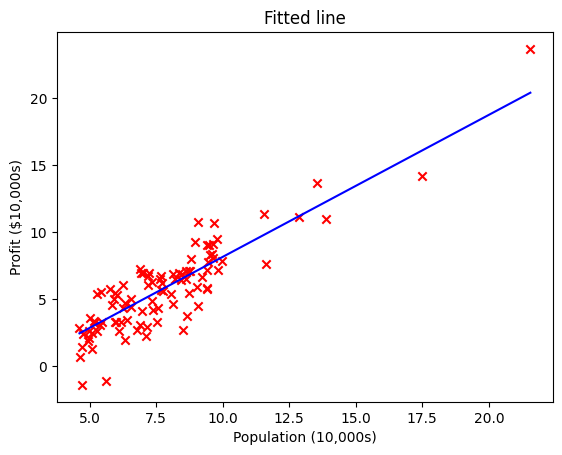

人口 35000 人，預測每月獲利 $12,662
人口 70000 人，預測每月獲利 $49,756


In [7]:
import copy
import math

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0.0
    dj_db = 0.0
    for i in range(m):
        error = w * x[i] + b - y[i]
        dj_dw += error * x[i]
        dj_db += error
    return dj_dw / m, dj_db / m

def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    w = copy.deepcopy(w_in)
    b = b_in
    history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        history.append(compute_cost(x, y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {history[-1]:8.2f}")
    return w, b, history

dj_dw, dj_db = compute_gradient(x_train, y_train, 0.0, 0.0)
print("w=0, b=0 的梯度", dj_dw, dj_db)
print("舊測驗參考值約 -52.755 與 -5.756")

w, b, history = gradient_descent(x_train, y_train, 0.0, 0.0, alpha=0.01, num_iters=1500)
print("學到的 w, b =", w, b)
print("舊測驗參考值約 w=1.060, b=-2.443")

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("Cost")
plt.title("Cost should fall, then flatten")
plt.show()

x_line = np.linspace(x_train.min(), x_train.max(), 50)
plt.scatter(x_train, y_train, marker="x", c="r")
plt.plot(x_line, w * x_line + b, c="b")
plt.xlabel("Population (10,000s)")
plt.ylabel("Profit ($10,000s)")
plt.title("Fitted line")
plt.show()

for population in (3.5, 7.0):
    profit = (population * w + b) * 10000
    print(f"人口 {population * 10000:.0f} 人，預測每月獲利 ${profit:,.0f}")


### 你的觀察

只寫你自己的話。agent 不要填。

1. 我從圖上看到：
2. 模型大概差多少。用獲利的金額講，不要只寫 Cost：
3. 哪一種城市我會不敢用這條線：
4. 如果我是執行長，我會先看哪些城市：


## 第二部：人口加上收入

同一間公司，這次每個城市有兩個數：人口，以及當地收入的指標。預測仍是每月獲利。

模型改成向量。`X` 的每一列是一個城市，`w` 有兩個數，一個對人口、一個對收入。

$$\hat{y} = Xw + b$$

`np.dot(X, w)` 就是每個城市把兩個特徵各乘上自己的 `w` 再相加。這是測驗 11 用的寫法，迴圈版和向量版算的是同一件事。


形狀 (47, 2) 特徵標準差 [6.00830471 1.88851684]


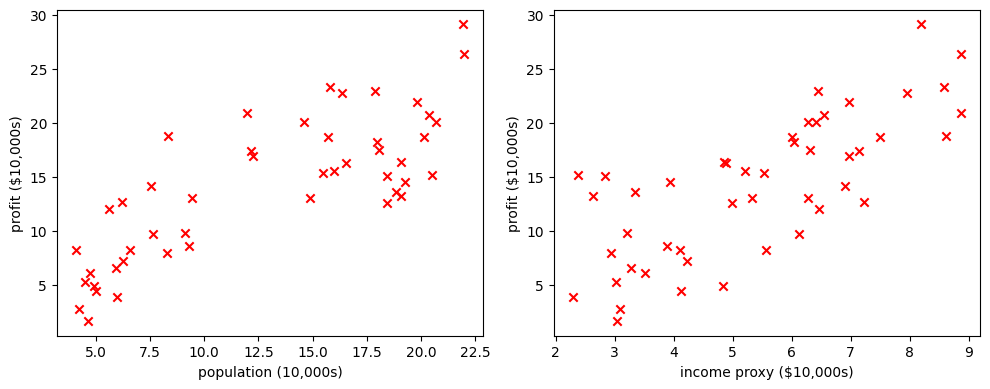

In [8]:
multi = np.loadtxt(DATA_DIR / "ex1data2.txt", delimiter=",")
X_train = multi[:, :2]
y_multi = multi[:, 2]
names = ["population (10,000s)", "income proxy ($10,000s)"]
print("形狀", X_train.shape, "特徵標準差", X_train.std(axis=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for j in range(2):
    axes[j].scatter(X_train[:, j], y_multi, marker="x", c="r")
    axes[j].set_xlabel(names[j])
    axes[j].set_ylabel("profit ($10,000s)")
plt.tight_layout()
plt.show()


## 尺度不同時，同一步長會踩太大

人口的變動範圍比收入大。梯度下降若用同一個 `alpha`，大尺度的特徵會把 `w` 推得很遠，Cost 可能先爆再亂跳。

z-score 是每個特徵先減自己的平均、再除以自己的標準差，讓兩個特徵都落在差不多的尺度。預測新城市時要用訓練時的平均和標準差，不能重新算一組。

下一格用同一個 `alpha=0.3` 跑原始資料和縮放後的資料。這是實驗格。


縮放後、w=0 的 Cost = 120.388
舊測驗參考值是 120.388
梯度 dj_dw [-5.13108179 -4.88920085] dj_db -14.111
舊測驗參考值約 dj_dw=[-5.131, -4.889], dj_db=-14.111
原始資料前 5 次 Cost [522183.38, 2380901453.51, 10855838939927.82, 4.949773922253383e+16, 2.2568741132768887e+20]
縮放後前 5 次 Cost [57.45, 27.99, 14.07, 7.44, 4.27]


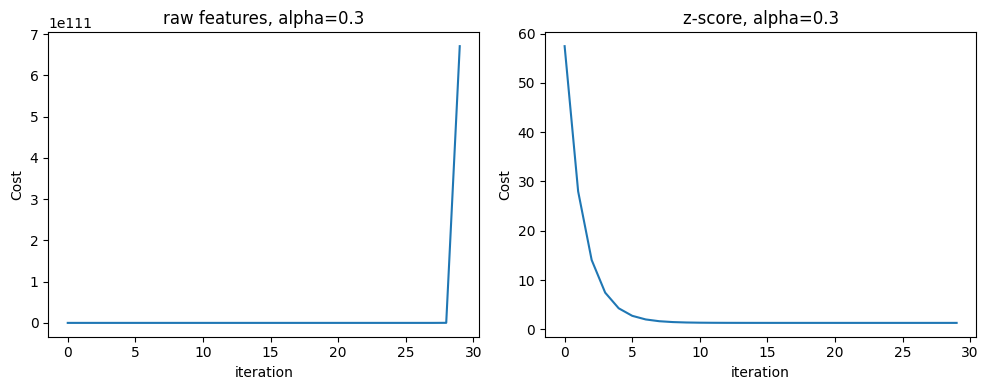

In [13]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    return (X - mu) / sigma, mu, sigma

def compute_cost_multi(X, y, w, b):
    m = X.shape[0]
    prediction = np.dot(X, w) + b
    return np.sum((prediction - y) ** 2) / (2 * m)

def compute_gradient_multi(X, y, w, b):
    m = X.shape[0]
    errors = np.dot(X, w) + b - y
    dj_dw = np.dot(X.T, errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent_multi(X, y, alpha, num_iters):
    w = np.zeros(X.shape[1])
    b = 0.0
    history = []
    for _ in range(num_iters):
        dj_dw, dj_db = compute_gradient_multi(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        history.append(compute_cost_multi(X, y, w, b))
    return w, b, history

X_norm, mu, sigma = zscore_normalize_features(X_train)
zeros_w = np.zeros(X_norm.shape[1])
print(f"縮放後、w=0 的 Cost = {compute_cost_multi(X_norm, y_multi, zeros_w, 0.0):.3f}")
print("舊測驗參考值是 120.388")
dj_dw, dj_db = compute_gradient_multi(X_norm, y_multi, zeros_w, 0.0)
print("梯度 dj_dw", dj_dw, "dj_db", round(float(dj_db), 3))
print("舊測驗參考值約 dj_dw=[-5.131, -4.889], dj_db=-14.111")

# 實驗：同一個 alpha。原始尺度的 Cost 會衝上去，縮放後才往下。
alpha = 0.3
_, _, raw_hist = gradient_descent_multi(X_train, y_multi, alpha, 30)
_, _, norm_hist = gradient_descent_multi(X_norm, y_multi, alpha, 30)
print("原始資料前 5 次 Cost", [round(float(v), 2) for v in raw_hist[:5]])
print("縮放後前 5 次 Cost", [round(float(v), 2) for v in norm_hist[:5]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(raw_hist)
axes[0].set_title("raw features, alpha=0.3")
axes[1].plot(norm_hist)
axes[1].set_title("z-score, alpha=0.3")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.set_ylabel("Cost")
plt.tight_layout()
plt.show()


學到的 w, b = [4.05204514 3.72240328] 14.0167993915659
舊測驗參考值約 w=[4.052, 3.722], b=14.017


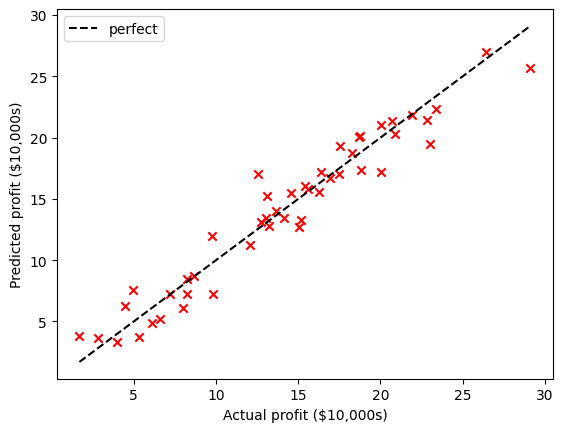

這個新城的預測獲利（萬美元） 19.313661208630403


In [12]:
w_multi, b_multi, history = gradient_descent_multi(X_norm, y_multi, alpha=0.005, num_iters=1000)
print("學到的 w, b =", w_multi, b_multi)
print("舊測驗參考值約 w=[4.052, 3.722], b=14.017")

y_pred = np.dot(X_norm, w_multi) + b_multi
plt.scatter(y_multi, y_pred, marker="x", c="r")
lims = [min(y_multi.min(), y_pred.min()), max(y_multi.max(), y_pred.max())]
plt.plot(lims, lims, "k--", label="perfect")
plt.xlabel("Actual profit ($10,000s)")
plt.ylabel("Predicted profit ($10,000s)")
plt.legend()
plt.show()

# 新城市要先用訓練時的 mu、sigma，再預測。
new_city = np.array([16.0, 7.0])  # 16 萬人、收入指標 7
new_norm = (new_city - mu) / sigma
print("這個新城的預測獲利（萬美元）", float(np.dot(new_norm, w_multi) + b_multi))


In [11]:
# 同一組縮放後的資料，用 sklearn 對一下係數。係數應接近上面的 w、b。
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_norm, y_multi)
print("sklearn w, b =", model.coef_, model.intercept_)
print("梯度下降 w, b =", w_multi, b_multi)
print("係數差", model.coef_ - w_multi, "截距差", model.intercept_ - b_multi)
print("兩邊是同一個直線模型。差一點通常是梯度下降的步數還沒走完。")


sklearn w, b = [4.06293245 3.72376134] 14.110691489361704
梯度下降 w, b = [4.05204514 3.72240328] 14.0167993915659
係數差 [0.01088732 0.00135806] 截距差 0.09389209779580376
兩邊是同一個直線模型。差一點通常是梯度下降的步數還沒走完。


### 你的觀察

只寫你自己的話。agent 不要填。

1. 兩個特徵裡，你覺得哪個和獲利的關係比較清楚：
2. 不縮放時 Cost 發生了什麼。縮放之後呢：
3. sklearn 的係數和自己跑的梯度下降差多少。差很大的話，你會先懷疑哪裡：
4. 若主管問「收入比較高的城市要不要優先開」，你會怎麼用這兩個 `w` 回答：


## 這本沒有收進來的

多項式、自己造特徵（舊的 08）是另一個問題：這關係根本不是直線時才需要。向量化的速度比較、以及 `public_tests` 批改，也不在這本。舊檔還在同一資料夾。
